## Project OID (Exploratory Data Analysis)
Processing the dataset collected from the experiment with various infill density and replicates (repeatability). 

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("PAASE Dataset.csv", header=3)

df.head()

,item_no,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,remarks
0,1,4/14/2026,15:04:53,15:14:15,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,09:22,1.41,1.44,0.014,NaN,NaN,Nagbedlevel kaya matagal (randomly)
1,2,4/14/2026,15:15:57,15:23:30,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:33,1.40,1.44,0.013,NaN,NaN,NaN
2,3,4/14/2026,15:25:15,15:33:12,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:57,1.40,1.44,0.013,NaN,NaN,NaN
3,4,4/14/2026,15:34:26,15:42:32,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,08:06,1.40,1.44,0.013,NaN,NaN,NaN
4,5,4/14/2026,15:43:59,15:51:56,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:57,1.41,1.44,0.013,NaN,NaN,NaN


In [76]:
df.drop(columns=["item_no","remarks"], inplace=True, errors='ignore')
df.head(10)

,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent
0,4/14/2026,15:04:53,15:14:15,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,09:22,1.41,1.44,0.014,NaN,NaN
1,4/14/2026,15:15:57,15:23:30,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:33,1.40,1.44,0.013,NaN,NaN
2,4/14/2026,15:25:15,15:33:12,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:57,1.40,1.44,0.013,NaN,NaN
3,4/14/2026,15:34:26,15:42:32,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,08:06,1.40,1.44,0.013,NaN,NaN
4,4/14/2026,15:43:59,15:51:56,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:57,1.41,1.44,0.013,NaN,NaN
5,4/14/2026,16:47:31,16:55:32,PLA_20_R1,1,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.46,1.49,0.011,NaN,NaN
6,4/14/2026,16:56:54,17:04:55,PLA_20_R2,2,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.46,1.49,0.012,NaN,NaN
7,4/14/2026,17:06:30,17:14:31,PLA_20_R3,3,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.46,1.49,0.013,NaN,NaN
8,4/14/2026,17:16:11,17:24:19,PLA_20_R4,4,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:08,1.47,1.49,0.012,NaN,NaN
9,4/14/2026,17:27:02,17:35:03,PLA_20_R5,5,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.47,1.49,0.013,NaN,NaN


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   print_date              50 non-null     object 
 1   start_time              50 non-null     object 
 2   end_time                50 non-null     object 
 3   specimen_id             50 non-null     object 
 4   replicate_no            50 non-null     int64  
 5   infill_density_percent  50 non-null     int64  
 6   infill_pattern          50 non-null     object 
 7   material_type           50 non-null     object 
 8   layer_height_mm         50 non-null     float64
 9   nozzle_temp_c           50 non-null     int64  
 10  bed_temp_c              50 non-null     int64  
 11  wall_count              50 non-null     int64  
 12  top_layers              50 non-null     int64  
 13  bottom_layers           50 non-null     int64  
 14  print_time_slicer       50 non-null     obje

In [78]:
# Reload dataframe to start fresh
df = pd.read_csv("PAASE Dataset.csv", header=3)
df.drop(columns=["item_no","remarks"], inplace=True, errors='ignore')

# Convert start_time and end_time to time objects
df['start_time'] = pd.to_datetime(df['start_time'], format='%H:%M:%S').dt.time
df['end_time'] = pd.to_datetime(df['end_time'], format='%H:%M:%S').dt.time

# Function to convert mm:ss to decimal minutes
def convert_mmss_to_minutes(time_str):
    if pd.isna(time_str):
        return 0.0
    parts = str(time_str).split(':')
    minutes = float(parts[0])
    seconds = float(parts[1]) if len(parts) > 1 else 0
    return minutes + seconds / 60

# Convert print_time_slicer and print_time_actual to decimal format (4 decimal places)
df['print_time_slicer'] = df['print_time_slicer'].apply(convert_mmss_to_minutes).round(4)
df['print_time_actual'] = df['print_time_actual'].apply(convert_mmss_to_minutes).round(4)

df.head(15)

,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent
0,4/14/2026,15:04:53,15:14:15,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2167,9.3667,1.41,1.44,0.014,NaN,NaN
1,4/14/2026,15:15:57,15:23:30,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2167,7.5500,1.40,1.44,0.013,NaN,NaN
2,4/14/2026,15:25:15,15:33:12,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2167,7.9500,1.40,1.44,0.013,NaN,NaN
3,4/14/2026,15:34:26,15:42:32,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2167,8.1000,1.40,1.44,0.013,NaN,NaN
4,4/14/2026,15:43:59,15:51:56,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2167,7.9500,1.41,1.44,0.013,NaN,NaN
5,4/14/2026,16:47:31,16:55:32,PLA_20_R1,1,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2500,8.0167,1.46,1.49,0.011,NaN,NaN
6,4/14/2026,16:56:54,17:04:55,PLA_20_R2,2,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2500,8.0167,1.46,1.49,0.012,NaN,NaN
7,4/14/2026,17:06:30,17:14:31,PLA_20_R3,3,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2500,8.0167,1.46,1.49,0.013,NaN,NaN
8,4/14/2026,17:16:11,17:24:19,PLA_20_R4,4,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2500,8.1333,1.47,1.49,0.012,NaN,NaN
9,4/14/2026,17:27:02,17:35:03,PLA_20_R5,5,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,3.2500,8.0167,1.47,1.49,0.013,NaN,NaN


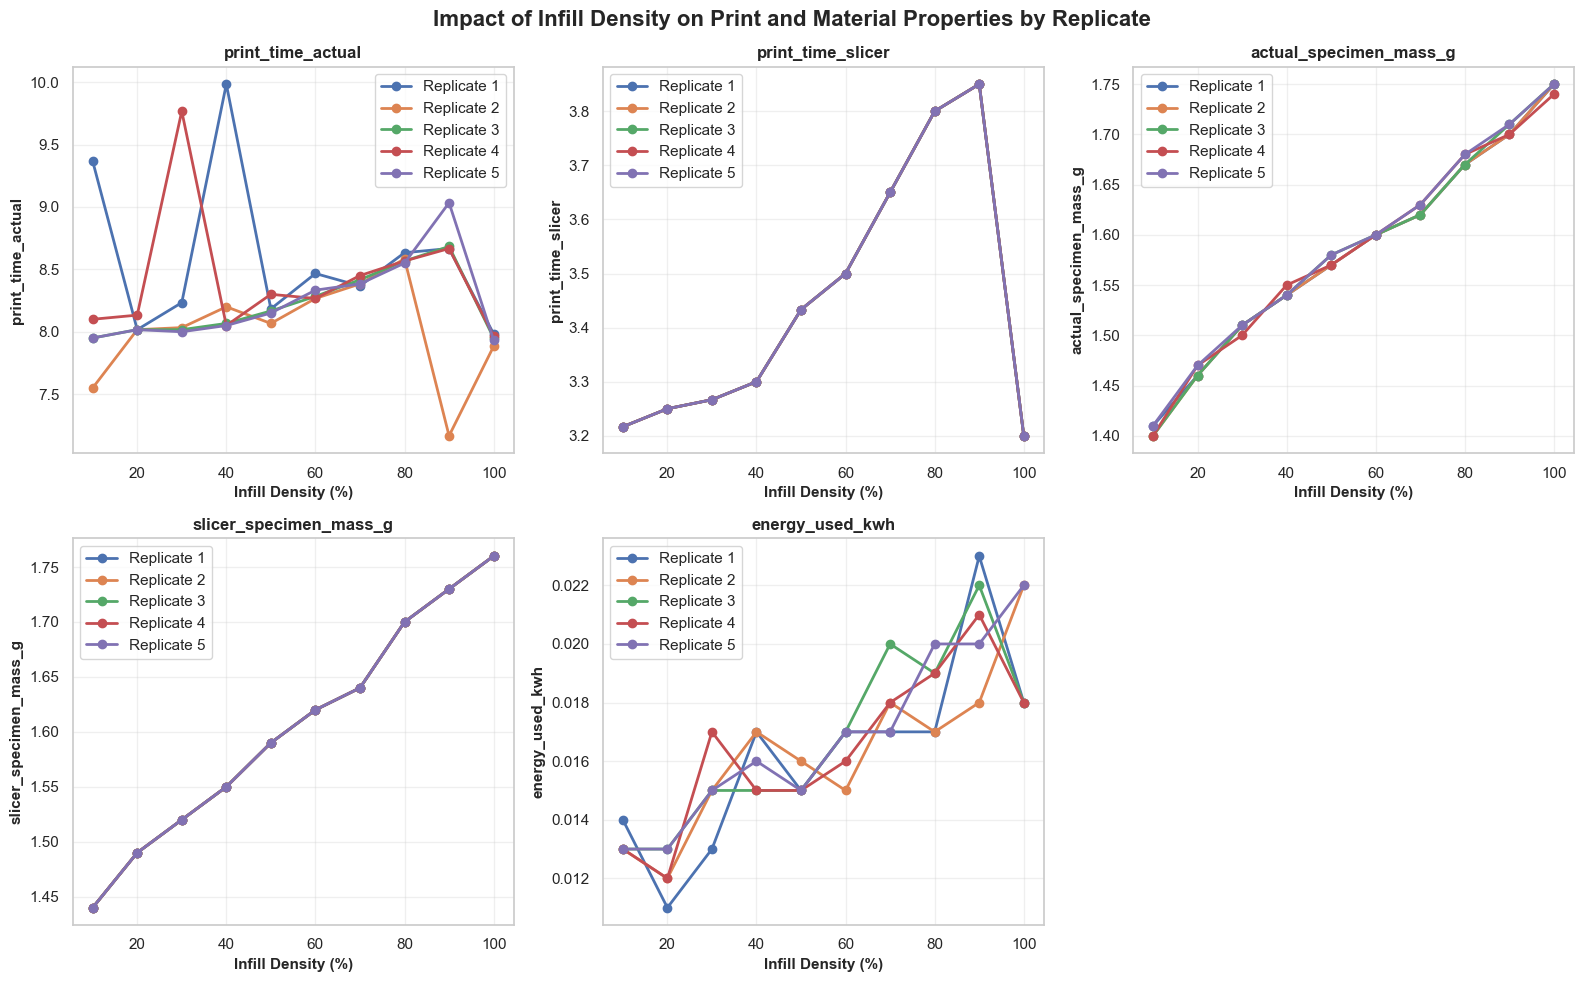

In [ ]:
# Visualization: Impact of infill density on metrics, grouped by replicate
analysis_columns = ['print_time_actual', 'print_time_slicer', 'actual_specimen_mass_g', 
                    'slicer_specimen_mass_g', 'energy_used_kwh']

# Create a figure with subplots for each metric
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Impact of Infill Density on Print and Material Properties by Replicate', fontsize=16, fontweight='bold')

# Flatten axes for easier iteration
axes = axes.flatten()

replicates = sorted(df['replicate_no'].unique())

for idx, col in enumerate(analysis_columns):
    ax = axes[idx]
    
    # Plot lines for each replicate
    for rep in replicates:
        rep_data = df[df['replicate_no'] == rep].sort_values('infill_density_percent')
        grouped_data = rep_data.groupby('infill_density_percent')[col].mean()
        
        ax.plot(grouped_data.index, grouped_data.values, marker='o', label=f'Replicate {int(rep)}', linewidth=2)
    
    ax.set_xlabel('Infill Density (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel(col, fontsize=11, fontweight='bold')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Add headroom on top
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + 0.1 * y_range)

# Remove the extra subplot

fig.delaxes(axes[5])

plt.show()
plt.tight_layout()

COMPREHENSIVE DATA ANALYSIS FRAMEWORK


C:\Users\saloj\AppData\Local\Temp\ipykernel_28888\1790079475.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='infill_density_percent', y=col, ax=axes[idx], palette='Set2')
C:\Users\saloj\AppData\Local\Temp\ipykernel_28888\1790079475.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='infill_density_percent', y=col, ax=axes[idx], palette='Set2')
C:\Users\saloj\AppData\Local\Temp\ipykernel_28888\1790079475.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='infill_density_percent', y=col, ax=axes[idx],

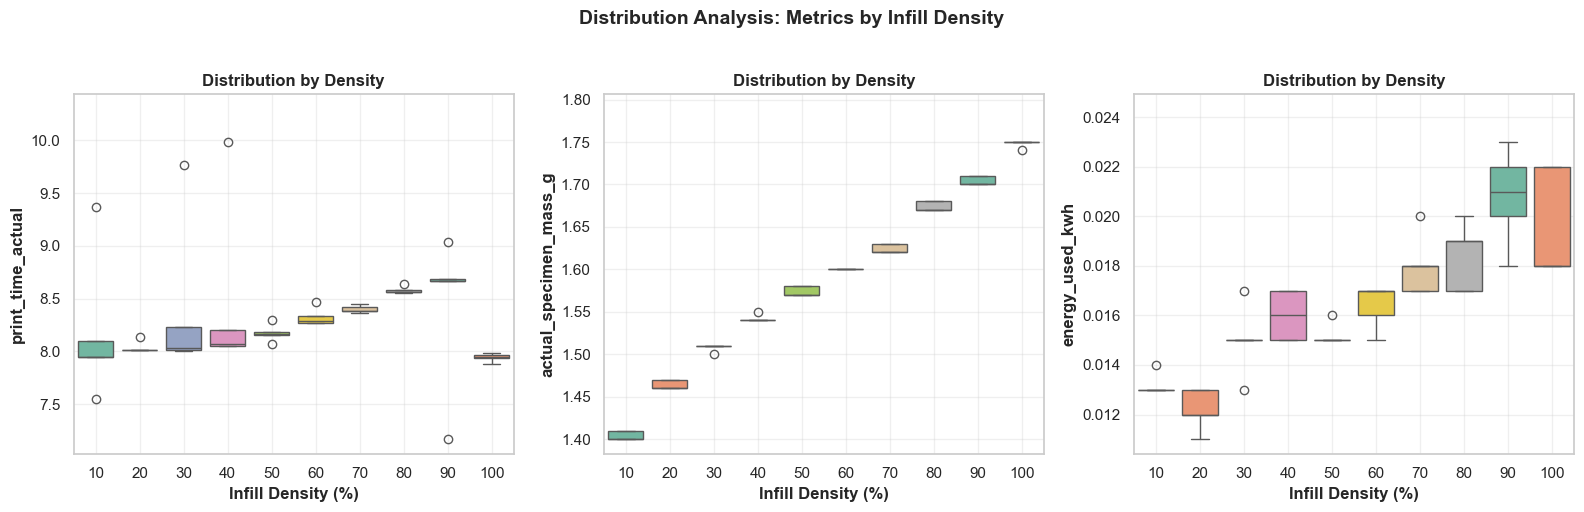

In [92]:
# COMPREHENSIVE ANALYSIS FRAMEWORK FOR RESEARCH STUDY
# Format: Publication-Ready Visualizations with Multiple Perspectives

print("="*100)
print("COMPREHENSIVE DATA ANALYSIS FRAMEWORK")
print("="*100)

analysis_columns = ['print_time_actual', 'print_time_slicer', 'actual_specimen_mass_g', 
                    'slicer_specimen_mass_g', 'energy_used_kwh']

# 1. BOX PLOTS BY DENSITY - Shows distribution and outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution Analysis: Metrics by Infill Density', fontsize=14, fontweight='bold', y=1.02)

metrics_for_box = ['print_time_actual', 'actual_specimen_mass_g', 'energy_used_kwh']

for idx, col in enumerate(metrics_for_box):
    sns.boxplot(data=df, x='infill_density_percent', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_xlabel('Infill Density (%)', fontweight='bold')
    axes[idx].set_ylabel(col, fontweight='bold')
    axes[idx].set_title(f'Distribution by Density', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add headroom on top
    y_min, y_max = axes[idx].get_ylim()
    y_range = y_max - y_min
    axes[idx].set_ylim(y_min, y_max + 0.1 * y_range)

plt.tight_layout()
plt.show()

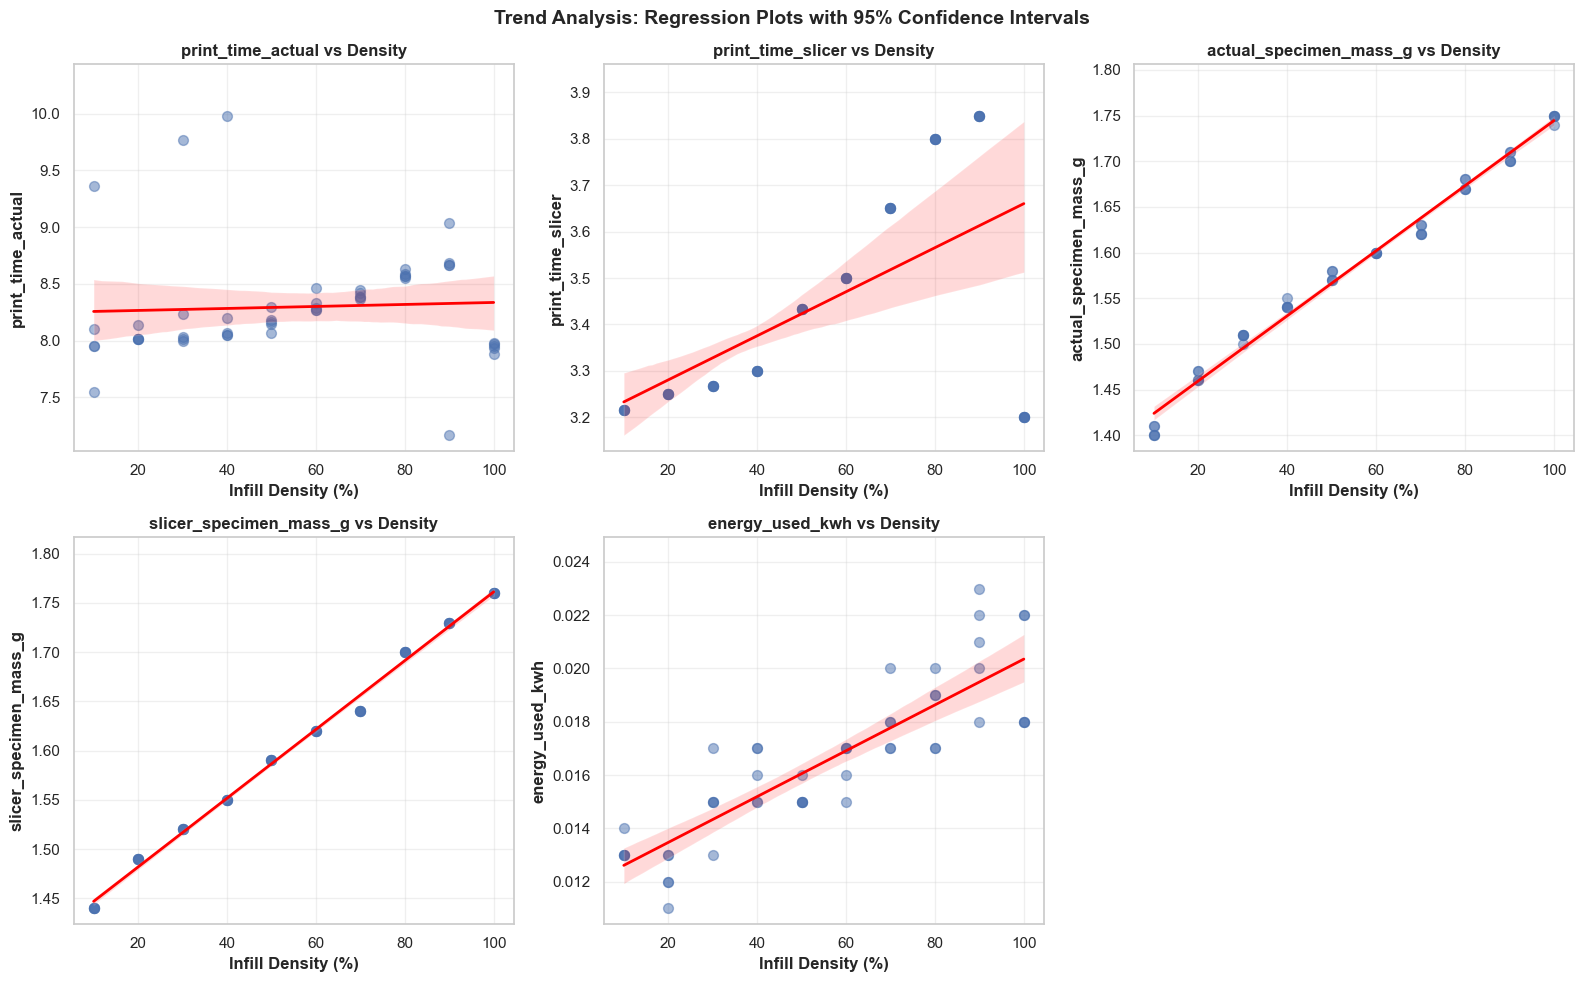

In [93]:
# 2. REGRESSION PLOTS WITH CONFIDENCE INTERVALS - Shows trends and uncertainty
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Trend Analysis: Regression Plots with 95% Confidence Intervals', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(analysis_columns):
    sns.regplot(data=df, x='infill_density_percent', y=col, ax=axes[idx], 
                scatter_kws={'alpha': 0.5, 's': 50}, line_kws={'color': 'red', 'linewidth': 2})
    axes[idx].set_xlabel('Infill Density (%)', fontweight='bold')
    axes[idx].set_ylabel(col, fontweight='bold')
    axes[idx].set_title(f'{col} vs Density', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add headroom on top
    y_min, y_max = axes[idx].get_ylim()
    y_range = y_max - y_min
    axes[idx].set_ylim(y_min, y_max + 0.1 * y_range)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

C:\Users\saloj\AppData\Local\Temp\ipykernel_28888\2121622465.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='replicate_no', y=col, ax=axes[idx], palette='muted')
C:\Users\saloj\AppData\Local\Temp\ipykernel_28888\2121622465.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='replicate_no', y=col, ax=axes[idx], palette='muted')
C:\Users\saloj\AppData\Local\Temp\ipykernel_28888\2121622465.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='replicate_no', y=col, ax=axes[idx], palette='muted')


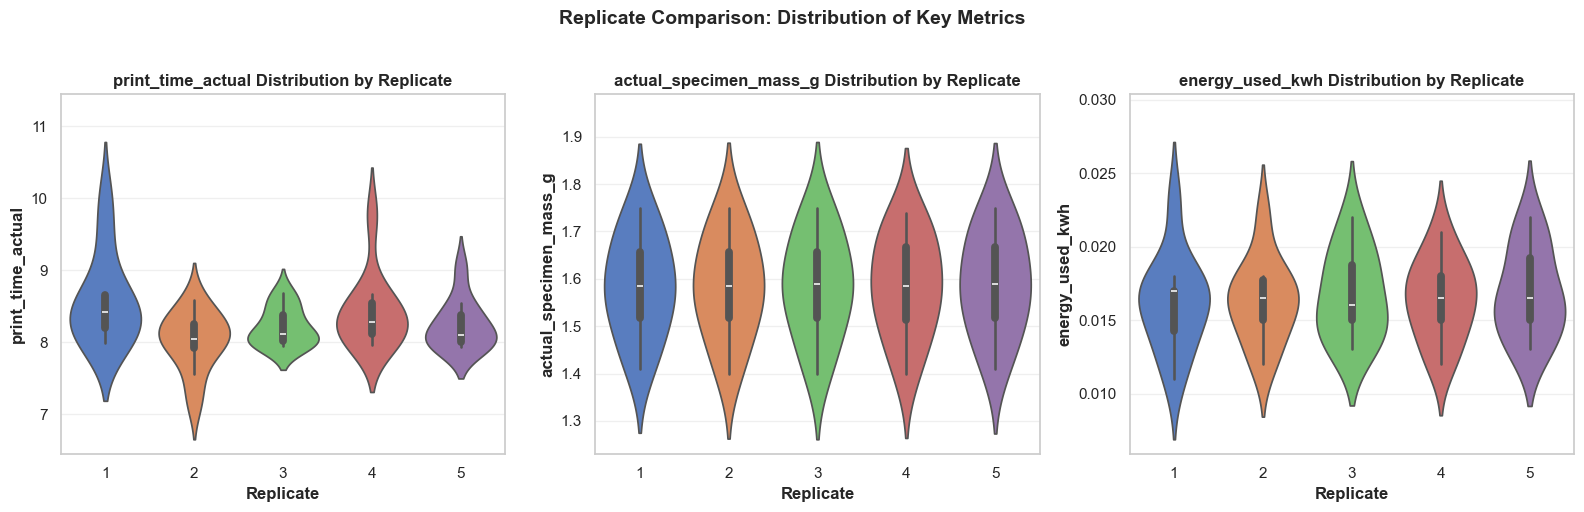

In [94]:
# 3. VIOLIN PLOTS BY REPLICATE - Shows distribution across replicates
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Replicate Comparison: Distribution of Key Metrics', fontsize=14, fontweight='bold', y=1.02)

for idx, col in enumerate(metrics_for_box):
    sns.violinplot(data=df, x='replicate_no', y=col, ax=axes[idx], palette='muted')
    axes[idx].set_xlabel('Replicate', fontweight='bold')
    axes[idx].set_ylabel(col, fontweight='bold')
    axes[idx].set_title(f'{col} Distribution by Replicate', fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add headroom on top
    y_min, y_max = axes[idx].get_ylim()
    y_range = y_max - y_min
    axes[idx].set_ylim(y_min, y_max + 0.1 * y_range)

plt.tight_layout()
plt.show()

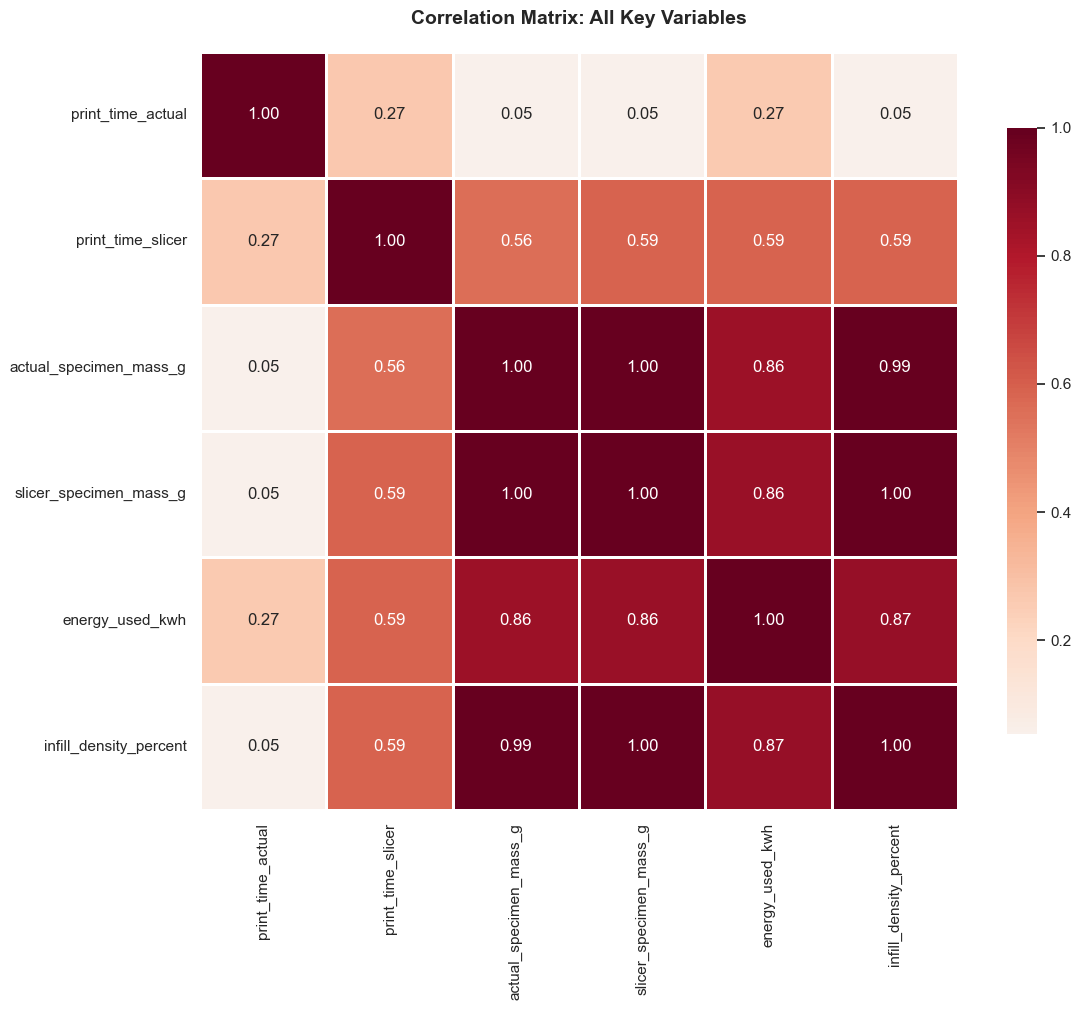

In [95]:
# 4. CORRELATION HEATMAP - Shows relationships between measurements

correlation_cols = ['print_time_actual', 'print_time_slicer', 'actual_specimen_mass_g', 'slicer_specimen_mass_g', 'energy_used_kwh', 'infill_density_percent']

correlation_matrix = df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix: All Key Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

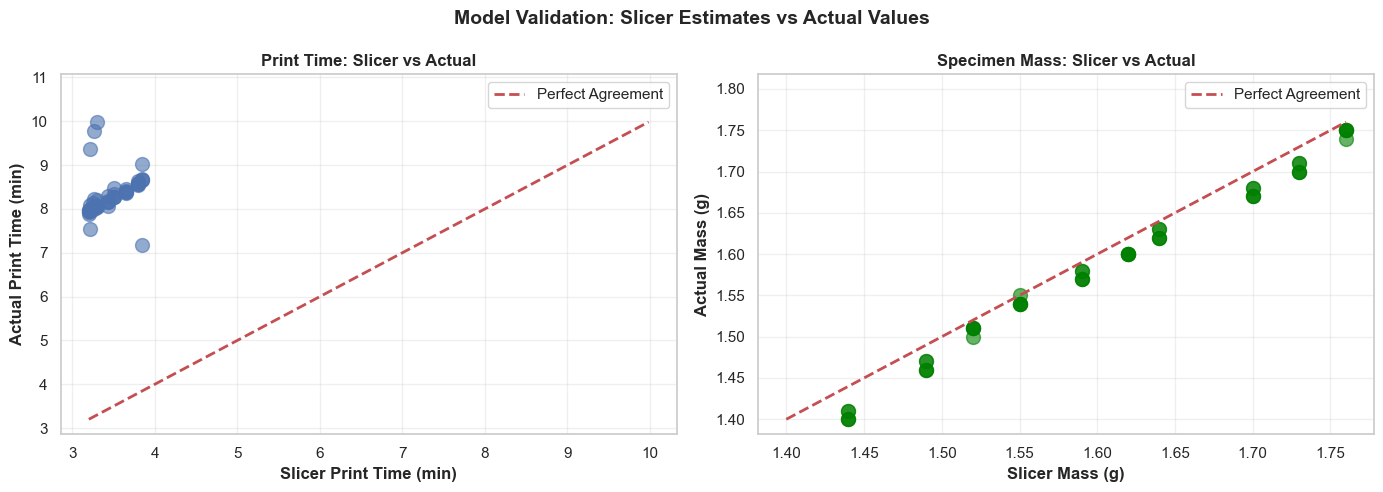

In [96]:
# 5. ACTUAL vs PREDICTED (SLICER) PLOTS - Model validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Validation: Slicer Estimates vs Actual Values', fontsize=14, fontweight='bold')

# Print time comparison
axes[0].scatter(df['print_time_slicer'], df['print_time_actual'], alpha=0.6, s=100)
min_val = min(df['print_time_slicer'].min(), df['print_time_actual'].min())
max_val = max(df['print_time_slicer'].max(), df['print_time_actual'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Agreement')
axes[0].set_xlabel('Slicer Print Time (min)', fontweight='bold')
axes[0].set_ylabel('Actual Print Time (min)', fontweight='bold')
axes[0].set_title('Print Time: Slicer vs Actual', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add headroom on top
y_min, y_max = axes[0].get_ylim()
y_range = y_max - y_min
axes[0].set_ylim(y_min, y_max + 0.1 * y_range)

# Mass comparison
axes[1].scatter(df['slicer_specimen_mass_g'], df['actual_specimen_mass_g'], alpha=0.6, s=100, color='green')
min_val = min(df['slicer_specimen_mass_g'].min(), df['actual_specimen_mass_g'].min())
max_val = max(df['slicer_specimen_mass_g'].max(), df['actual_specimen_mass_g'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Agreement')
axes[1].set_xlabel('Slicer Mass (g)', fontweight='bold')
axes[1].set_ylabel('Actual Mass (g)', fontweight='bold')
axes[1].set_title('Specimen Mass: Slicer vs Actual', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add headroom on top
y_min, y_max = axes[1].get_ylim()
y_range = y_max - y_min
axes[1].set_ylim(y_min, y_max + 0.1 * y_range)

plt.tight_layout()
plt.show()